# 🧹 PT yang ada di indonesia
 MMS — Data Cleaning Pipeline

Notebook ini melakukan proses **Data Cleaning** lengkap sebelum dataset digunakan untuk training AI model.

## Tahapan Cleaning:
| # | Tahap | Keterangan |
|---|-------|------------|
| 1 | **Load Data** | Baca semua CSV processed |
| 2 | **Missing Values** | Identifikasi & imputasi nilai yang hilang |
| 3 | **Duplikasi** | Deteksi & hapus baris duplikat |
| 4 | **Outlier** | Deteksi (IQR + Z-Score) & penanganan |
| 5 | **Tipe Data & Format** | Standarisasi dtype, parse datetime |
| 6 | **Fitur Tidak Relevan** | Hapus kolom low-variance & redundan |
| 7 | **Inkonsistensi Struktural** | Perbaiki kategori & encoding |
| 8 | **Validasi Akhir** | Cek dataset bersih siap pakai |
| 9 | **Simpan** | Export dataset bersih ke CSV & format lain |

---
**Input :** `dataset/processed/df_model_full.csv`  
**Output:** `dataset/processed/df_cleaned.csv` + laporan cleaning

---
## 📦 1. Import Library & Konfigurasi

In [1]:
import os
import warnings
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

plt.rcParams.update({
    'figure.figsize'   : (14, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})
sns.set_palette('tab10')

# ── Tentukan path project secara absolut ──────────────────────────────────────
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
PROCESSED_DIR = PROJECT_ROOT / 'dataset' / 'processed'

assert PROCESSED_DIR.exists(), (
    f'❌ Folder processed tidak ada: {PROCESSED_DIR}\n'
    f'   Jalankan dulu notebook explorations.ipynb hingga selesai!'
)

print('✅ Import sukses!')
print(f'📂 Project root  : {PROJECT_ROOT}')
print(f'📂 Processed dir : {PROCESSED_DIR}')
print()
print('📋 File yang tersedia:')
for f in sorted(PROCESSED_DIR.iterdir()):
    print(f'   · {f.name:45s} {f.stat().st_size/1024:>8.1f} KB')

✅ Import sukses!
📂 Project root  : c:\AI\AI untuk Dashboard TA\New folder
📂 Processed dir : c:\AI\AI untuk Dashboard TA\New folder\dataset\processed

📋 File yang tersedia:
   · df_cleaned.csv                                  1330.7 KB
   · df_cleaned_efficiency_forecast.csv              1014.0 KB
   · df_cleaned_oee_prediction.csv                   1091.0 KB
   · df_cleaned_output_forecast.csv                  1000.1 KB
   · df_cleaned_reject_prediction.csv                 986.3 KB
   · df_efficiency_forecast.csv                      1061.8 KB
   · df_model_full.csv                               1340.0 KB
   · df_oee_prediction.csv                           1138.9 KB
   · df_output_forecast.csv                          1074.2 KB
   · df_reject_prediction.csv                        1046.5 KB
   · line.csv                                           0.4 KB
   · machine.csv                                        1.5 KB
   · pn.csv                                             0.9 KB
   · proc

---
## 📥 2. Load Dataset

In [2]:
# Load dataset gabungan utama
INPUT_FILE = PROCESSED_DIR / 'df_model_full.csv'
df_raw = pd.read_csv(INPUT_FILE)

# Simpan snapshot awal untuk laporan
ORIGINAL_SHAPE = df_raw.shape

print(f'✅ Dataset berhasil diload!')
print(f'   Shape    : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} kolom')
print(f'   Memori   : {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print()
print('🔎 5 baris pertama:')
df_raw.head()

✅ Dataset berhasil diload!
   Shape    : 6,340 rows × 27 kolom
   Memori   : 2.19 MB

🔎 5 baris pertama:


,recorded_date,line_name,shift_name,recorded_hour,day_of_week,week_of_year,month,is_weekend,shift_num,line_encoded,total_output,total_pass,total_reject,reject_rate,pass_rate,downtime_rate,avg_sec_per_unit,availability,perfomance,quality,total_downtime_seconds,downtime_count,troughput,oee_line,total_output.1,total_reject.1,efficiency
0,2026-02-01,Line A,Shift 1,6,6,5,2,1,1,0,850,4,0,0.0000,0.0047,0.0000,33.8824,0.9715,0.7812,0.9603,0,0,126.6647,0.7269,850,0,0.6635
1,2026-02-01,Line A,Shift 2,14,6,5,2,1,2,0,894,5,0,0.0000,0.0056,0.0000,32.2148,0.9732,0.7721,0.9673,0,0,126.5353,0.7262,894,0,0.6249
2,2026-02-02,Line A,Shift 3,22,0,6,2,0,3,0,1050,4,0,0.0000,0.0038,0.0000,27.4286,0.9726,0.7704,0.9544,0,0,128.1518,0.7158,1050,0,0.4120
3,2026-02-01,Line A,Shift 1,6,6,5,2,1,1,0,700,5,0,0.0000,0.0071,0.0000,41.1429,0.9580,0.6420,0.9496,0,0,99.0782,0.5805,700,0,0.8529
4,2026-02-01,Line A,Shift 2,14,6,5,2,1,2,0,925,2,1,0.0011,0.0022,0.0000,31.1351,0.9596,0.6537,0.9768,0,0,99.8704,0.6099,925,1,0.4722


In [3]:
# Overview semua kolom
print('📊 Info Kolom:')
print(f'   {"Kolom":<30} {"Dtype":<12} {"Non-Null":>8} {"Null":>6} {"Null%":>7} {"Unique":>8}')
print('   ' + '-' * 75)
for col in df_raw.columns:
    null_n   = df_raw[col].isna().sum()
    null_pct = null_n / len(df_raw) * 100
    unique   = df_raw[col].nunique()
    dtype    = str(df_raw[col].dtype)
    print(f'   {col:<30} {dtype:<12} {len(df_raw)-null_n:>8,} {null_n:>6,} {null_pct:>6.1f}% {unique:>8,}')

📊 Info Kolom:
   Kolom                          Dtype        Non-Null   Null   Null%   Unique
   ---------------------------------------------------------------------------
   recorded_date                  str             6,340      0    0.0%      182
   line_name                      str             6,340      0    0.0%        4
   shift_name                     str             6,340      0    0.0%        3
   recorded_hour                  int64           6,340      0    0.0%        3
   day_of_week                    int64           6,340      0    0.0%        7
   week_of_year                   int64           6,340      0    0.0%       27
   month                          int64           6,340      0    0.0%        7
   is_weekend                     int64           6,340      0    0.0%        2
   shift_num                      int64           6,340      0    0.0%        3
   line_encoded                   int64           6,340      0    0.0%        4
   total_output            

In [4]:
# ── Log untuk laporan cleaning ─────────────────────────────────────────────────
cleaning_log = []

def log_step(step: str, desc: str, before: int, after: int, detail: str = ''):
    """Catat setiap langkah cleaning."""
    removed = before - after
    pct     = removed / before * 100 if before else 0
    entry   = {
        'step'   : step,
        'desc'   : desc,
        'before' : before,
        'after'  : after,
        'removed': removed,
        'pct'    : round(pct, 2),
        'detail' : detail,
    }
    cleaning_log.append(entry)
    icon = '✅' if removed == 0 else '🔧'
    print(f'{icon} [{step}] {desc}')
    if removed:
        print(f'   {before:,} → {after:,} (hapus {removed:,} baris / {pct:.2f}%)')
    if detail:
        print(f'   Detail: {detail}')

# Salin untuk mulai proses
df = df_raw.copy()
print(f'✅ Cleaning log diinisialisasi.')
print(f'   Dataset awal: {df.shape[0]:,} rows × {df.shape[1]} kolom')

✅ Cleaning log diinisialisasi.
   Dataset awal: 6,340 rows × 27 kolom


---
## 🕳️ 3. Penanganan Missing Values

In [5]:
# ── 3.1 Deteksi Missing Values ─────────────────────────────────────────────────
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_%'    : (df.isnull().mean() * 100).round(2),
    'dtype'     : df.dtypes,
}).sort_values('null_count', ascending=False)

cols_with_null = null_summary[null_summary['null_count'] > 0]

print(f'📋 Kolom dengan Missing Values: {len(cols_with_null)}')
if len(cols_with_null):
    print(cols_with_null.to_string())
else:
    print('   ✅ Tidak ada missing values!')

# Visualisasi missing values
if len(cols_with_null):
    fig, ax = plt.subplots(figsize=(12, max(4, len(cols_with_null) * 0.5)))
    bars = ax.barh(cols_with_null.index, cols_with_null['null_%'], color='salmon')
    ax.bar_label(bars, fmt='{:.1f}%', padding=3)
    ax.set_title('Missing Values per Kolom (%)')
    ax.set_xlabel('Missing %')
    ax.set_xlim(0, 110)
    plt.tight_layout()
    plt.show()

📋 Kolom dengan Missing Values: 0
   ✅ Tidak ada missing values!


In [6]:
# ── 3.2 Strategi Imputasi per Kolom ───────────────────────────────────────────
# Kolom numerik: isi dengan median (robust terhadap outlier)
# Kolom kategorikal: isi dengan modus

NUMERIC_COLS   = df.select_dtypes(include='number').columns.tolist()
CATEGORIC_COLS = df.select_dtypes(include='object').columns.tolist()

imputation_report = {}

for col in NUMERIC_COLS:
    n_null = df[col].isna().sum()
    if n_null > 0:
        pct_null = n_null / len(df) * 100
        if pct_null >= 50:
            # Terlalu banyak null → hapus kolom
            df.drop(columns=[col], inplace=True)
            imputation_report[col] = f'HAPUS (null {pct_null:.1f}% ≥ 50%)'
        else:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            imputation_report[col] = f'Median imputasi → {median_val:.4f} ({n_null} nilai)'

for col in CATEGORIC_COLS:
    n_null = df[col].isna().sum()
    if n_null > 0:
        pct_null = n_null / len(df) * 100
        if pct_null >= 50:
            df.drop(columns=[col], inplace=True)
            imputation_report[col] = f'HAPUS (null {pct_null:.1f}% ≥ 50%)'
        else:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            imputation_report[col] = f'Mode imputasi → "{mode_val}" ({n_null} nilai)'

print('📋 Laporan Imputasi Missing Values:')
if imputation_report:
    for col, action in imputation_report.items():
        print(f'   · {col:<35} → {action}')
else:
    print('   ✅ Tidak ada kolom yang memerlukan imputasi.')

total_null_after = df.isnull().sum().sum()
print(f'\n✅ Total missing setelah imputasi: {total_null_after}')
log_step('Missing Values', 'Imputasi missing values selesai', ORIGINAL_SHAPE[0], len(df),
         f'{len(imputation_report)} kolom ditangani')

📋 Laporan Imputasi Missing Values:
   ✅ Tidak ada kolom yang memerlukan imputasi.

✅ Total missing setelah imputasi: 0
✅ [Missing Values] Imputasi missing values selesai
   Detail: 0 kolom ditangani


---
## 👯 4. Penanganan Duplikasi

In [7]:
# ── 4.1 Deteksi Duplikat ───────────────────────────────────────────────────────
n_before = len(df)

# Duplikat persis (semua kolom sama)
n_exact_dup = df.duplicated().sum()
print(f'📋 Duplikat Terdeteksi:')
print(f'   Duplikat persis (semua kolom) : {n_exact_dup:,}')

# Cek kolom subset kunci
key_cols_exist = [c for c in ['recorded_date', 'line_name', 'shift_name', 'line_process_id'] if c in df.columns]
if key_cols_exist:
    n_key_dup = df.duplicated(subset=key_cols_exist).sum()
    print(f'   Duplikat kunci ({key_cols_exist}) : {n_key_dup:,}')

# Tampilkan contoh duplikat jika ada
if n_exact_dup > 0:
    print(f'\n🔎 Contoh baris duplikat:')
    print(df[df.duplicated(keep=False)].head(6).to_string())
else:
    print('\n✅ Tidak ada duplikat persis ditemukan!')

📋 Duplikat Terdeteksi:
   Duplikat persis (semua kolom) : 0
   Duplikat kunci (['recorded_date', 'line_name', 'shift_name']) : 4,168

✅ Tidak ada duplikat persis ditemukan!


In [8]:
# ── 4.2 Hapus Duplikat ────────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

log_step('Duplikasi', 'Hapus baris duplikat', before, after,
         f'{before - after} baris duplikat dihapus')

# Verifikasi
print(f'\n✅ Dataset setelah deduplikasi: {df.shape[0]:,} rows × {df.shape[1]} kolom')
assert df.duplicated().sum() == 0, '❌ Masih ada duplikat!'
print('✅ Verifikasi: 0 duplikat tersisa.')

✅ [Duplikasi] Hapus baris duplikat
   Detail: 0 baris duplikat dihapus

✅ Dataset setelah deduplikasi: 6,340 rows × 27 kolom
✅ Verifikasi: 0 duplikat tersisa.


---
## 📐 5. Standarisasi Tipe Data & Format

In [9]:
# ── 5.1 Cek Tipe Data Saat Ini ────────────────────────────────────────────────
print('📋 Tipe Data Sebelum Standarisasi:')
dtype_df = pd.DataFrame({'dtype': df.dtypes, 'sample': df.iloc[0]})
print(dtype_df.to_string())

📋 Tipe Data Sebelum Standarisasi:
                          dtype      sample
recorded_date               str  2026-02-01
line_name                   str      Line A
shift_name                  str     Shift 1
recorded_hour             int64           6
day_of_week               int64           6
week_of_year              int64           5
month                     int64           2
is_weekend                int64           1
shift_num                 int64           1
line_encoded              int64           0
total_output              int64         850
total_pass                int64           4
total_reject              int64           0
reject_rate             float64      0.0000
pass_rate               float64      0.0047
downtime_rate           float64      0.0000
avg_sec_per_unit        float64     33.8824
availability            float64      0.9715
perfomance              float64      0.7812
quality                 float64      0.9603
total_downtime_seconds    int64           

In [10]:
# ── 5.2 Konversi Tipe Data ────────────────────────────────────────────────────
dtype_log = []

# (A) Kolom tanggal → datetime
date_cols = [c for c in df.columns if 'date' in c.lower() or 'created' in c.lower() or 'updated' in c.lower()]
for col in date_cols:
    if df[col].dtype == object:
        try:
            df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)
            dtype_log.append((col, 'object', 'datetime64[ns, UTC]'))
            print(f'   📅 {col} → datetime')
        except Exception as e:
            print(f'   ⚠️  {col} gagal konversi: {e}')

# (B) Kolom numerik yang tersimpan sebagai string → float
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    # Coba konversi ke numerik
    converted = pd.to_numeric(df[col], errors='coerce')
    # Jika > 90% berhasil konversi, jadikan numerik
    pct_convertible = converted.notna().mean()
    if pct_convertible >= 0.9:
        df[col] = converted
        dtype_log.append((col, 'object', 'float64 (auto-converted)'))
        print(f'   🔢 {col} → float64 ({pct_convertible*100:.0f}% berhasil)')

# (C) Kolom boolean yang mungkin tersimpan sebagai integer
int_cols = df.select_dtypes(include='int64').columns
potential_bool = [c for c in int_cols if df[c].nunique() <= 2 and set(df[c].unique()).issubset({0, 1})]
for col in potential_bool:
    df[col] = df[col].astype('int8')  # Hemat memori
    dtype_log.append((col, 'int64', 'int8 (boolean-like)'))
    print(f'   🔘 {col} → int8 (boolean-like, hemat memori)')

# (D) Kolom integer besar → downcast
int64_cols = df.select_dtypes(include='int64').columns
for col in int64_cols:
    df[col] = pd.to_numeric(df[col], downcast='integer')

# (E) Kolom float64 → float32 jika tidak memerlukan presisi tinggi
float64_cols = df.select_dtypes(include='float64').columns
HIGH_PRECISION_COLS = ['oee_line', 'availability', 'perfomance', 'quality',
                       'efficiency', 'reject_rate', 'pass_rate']
for col in float64_cols:
    if col not in HIGH_PRECISION_COLS:
        df[col] = df[col].astype('float32')

print(f'\n✅ Konversi tipe data selesai. {len(dtype_log)} kolom dikonversi.')
print(f'   Memori setelah optimasi: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

   🔘 is_weekend → int8 (boolean-like, hemat memori)

✅ Konversi tipe data selesai. 1 kolom dikonversi.
   Memori setelah optimasi: 1.54 MB


In [11]:
# ── 5.3 Standarisasi Format String ───────────────────────────────────────────
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    # Strip whitespace & lowercase untuk kategorikal
    df[col] = df[col].astype(str).str.strip()
    # Cek apakah kategorikal (nunique < 50)
    if df[col].nunique() < 50:
        df[col] = df[col].str.lower()
        print(f'   🔤 {col} → lowercase (nunique={df[col].nunique()})')

# Cek tipe data akhir
print('\n📋 Tipe Data Setelah Standarisasi:')
dtype_summary = df.dtypes.value_counts()
print(dtype_summary.to_string())
print(f'\n   Memori akhir: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

   🔤 line_name → lowercase (nunique=4)
   🔤 shift_name → lowercase (nunique=3)

📋 Tipe Data Setelah Standarisasi:
int8       11
float64     7
str         3
int16       3
float32     3

   Memori akhir: 1.54 MB


---
## 🗑️ 6. Hapus Fitur Tidak Relevan

In [12]:
# ── 6.1 Analisis Variance & Relevansi ─────────────────────────────────────────
n_cols_before = df.shape[1]
cols_to_drop   = []
drop_reasons   = {}

num_df = df.select_dtypes(include='number')

for col in df.columns:
    reason = None

    # (A) Kolom konstantan (variance = 0 atau 1 unique value)
    if df[col].nunique() <= 1:
        reason = f'Konstan (unique={df[col].nunique()})'

    # (B) Kolom ID / UUID (tidak relevan untuk ML)
    elif col.endswith('_id') or col == 'id':
        reason = 'Kolom ID/UUID (tidak informatif untuk ML)'

    # (C) Kolom numerik dengan variance sangat rendah (< 0.0001)
    elif col in num_df.columns:
        col_std = num_df[col].std()
        if pd.notna(col_std) and col_std < 0.0001 and num_df[col].nunique() < 3:
            reason = f'Low variance (std={col_std:.6f})'

    # (D) Kolom duplikat dari fitur yang sudah ada
    if col == 'target_output':
        reason = 'Konstan = 1000, tidak informatif'
    elif col == 'planned_time_seconds':
        reason = 'Konstan = 28800, tidak informatif'

    if reason:
        cols_to_drop.append(col)
        drop_reasons[col] = reason

print(f'📋 Kolom yang Akan Dihapus ({len(cols_to_drop)}):')
for col, reason in drop_reasons.items():
    print(f'   · {col:<35} → {reason}')

if not cols_to_drop:
    print('   ✅ Tidak ada kolom yang perlu dihapus.')

📋 Kolom yang Akan Dihapus (0):
   ✅ Tidak ada kolom yang perlu dihapus.


In [13]:
# ── 6.2 Cek Korelasi Tinggi (Redundan) ────────────────────────────────────────
CORR_THRESHOLD = 0.95

num_df_clean = df.select_dtypes(include='number').drop(columns=cols_to_drop, errors='ignore')
corr_matrix  = num_df_clean.corr().abs()

# Ambil pasangan kolom dengan korelasi > threshold (hanya upper triangle)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(row, col, upper_tri.loc[row, col])
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if upper_tri.loc[row, col] > CORR_THRESHOLD]

print(f'📋 Pasangan Kolom dengan Korelasi > {CORR_THRESHOLD}:')
redundant_cols = set()
if high_corr_pairs:
    for col1, col2, corr_val in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f'   · {col1} ↔ {col2}  corr={corr_val:.4f}')
        # Hapus kolom kedua dari setiap pasangan (yang datang belakangan)
        redundant_cols.add(col2)
    print(f'\n   Akan hapus kolom redundan: {list(redundant_cols)}')
else:
    print('   ✅ Tidak ada pasangan kolom dengan korelasi sangat tinggi.')

# Tambahkan ke daftar hapus
for col in redundant_cols:
    if col not in cols_to_drop:
        cols_to_drop.append(col)
        drop_reasons[col] = f'Redundan (korelasi > {CORR_THRESHOLD})'

📋 Pasangan Kolom dengan Korelasi > 0.95:
   · recorded_hour ↔ shift_num  corr=1.0000
   · total_output ↔ total_output.1  corr=1.0000
   · total_reject ↔ total_reject.1  corr=1.0000
   · downtime_rate ↔ total_downtime_seconds  corr=1.0000
   · perfomance ↔ oee_line  corr=0.9918
   · total_output ↔ avg_sec_per_unit  corr=0.9859
   · avg_sec_per_unit ↔ total_output.1  corr=0.9859
   · week_of_year ↔ month  corr=0.9854
   · total_reject ↔ reject_rate  corr=0.9843
   · reject_rate ↔ total_reject.1  corr=0.9843
   · troughput ↔ oee_line  corr=0.9699
   · perfomance ↔ troughput  corr=0.9639

   Akan hapus kolom redundan: ['avg_sec_per_unit', 'total_output.1', 'reject_rate', 'total_downtime_seconds', 'month', 'troughput', 'oee_line', 'total_reject.1', 'shift_num']


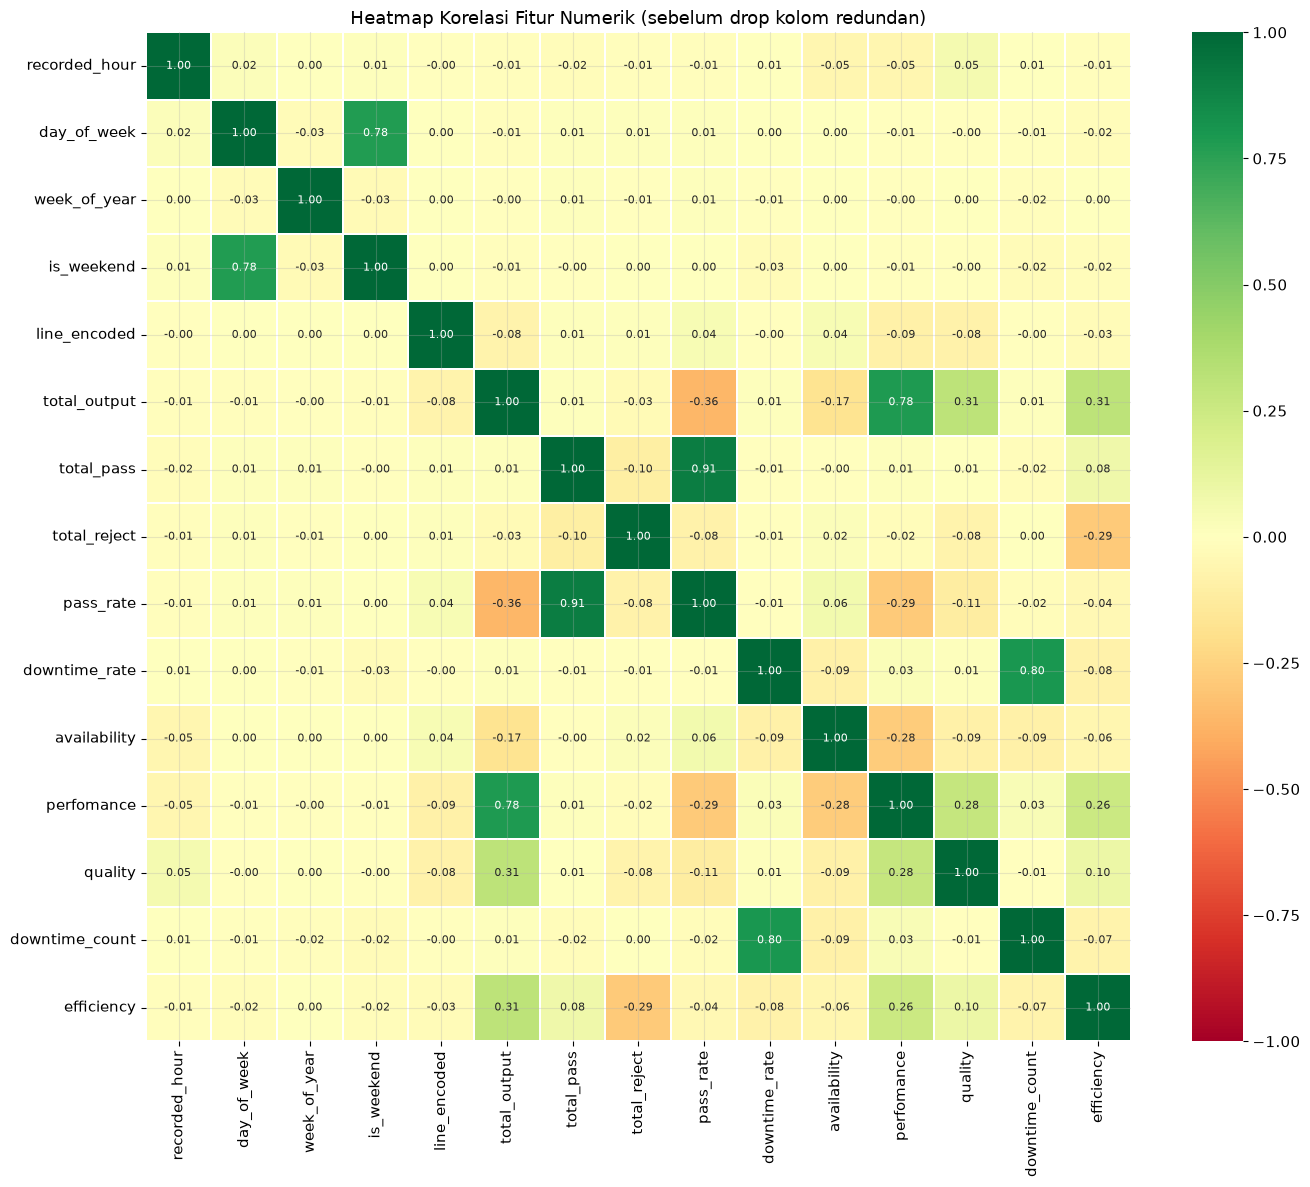

In [14]:
# Visualisasi heatmap korelasi (sebelum drop)
important_num_cols = [
    c for c in num_df_clean.columns
    if c not in cols_to_drop and c in df.columns
][:15]  # Batasi 15 kolom teratas

if len(important_num_cols) > 2:
    corr_vis = df[important_num_cols].corr()
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_vis, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, vmin=-1, vmax=1, ax=ax,
                linewidths=0.3, annot_kws={'size': 8})
    ax.set_title('Heatmap Korelasi Fitur Numerik (sebelum drop kolom redundan)')
    plt.tight_layout()
    plt.show()

In [15]:
# ── 6.3 Eksekusi Drop Kolom ───────────────────────────────────────────────────
cols_to_drop_existing = [c for c in cols_to_drop if c in df.columns]
before_cols = df.shape[1]

df.drop(columns=cols_to_drop_existing, inplace=True, errors='ignore')
after_cols = df.shape[1]

print(f'🗑️  Kolom dihapus : {before_cols - after_cols}')
print(f'✅ Kolom tersisa : {after_cols}')
print(f'\n📋 Kolom yang tersisa setelah pembersihan fitur:')
for i, col in enumerate(df.columns, 1):
    print(f'   {i:>2}. {col} ({df[col].dtype})')

🗑️  Kolom dihapus : 9
✅ Kolom tersisa : 18

📋 Kolom yang tersisa setelah pembersihan fitur:
    1. recorded_date (str)
    2. line_name (str)
    3. shift_name (str)
    4. recorded_hour (int8)
    5. day_of_week (int8)
    6. week_of_year (int8)
    7. is_weekend (int8)
    8. line_encoded (int8)
    9. total_output (int16)
   10. total_pass (int8)
   11. total_reject (int8)
   12. pass_rate (float64)
   13. downtime_rate (float32)
   14. availability (float64)
   15. perfomance (float64)
   16. quality (float64)
   17. downtime_count (int8)
   18. efficiency (float64)


---
## 📊 7. Penanganan Outlier

In [16]:
# ── 7.1 Deteksi Outlier dengan IQR & Z-Score ──────────────────────────────────

# Kolom yang akan dicek outlier (kolom numerik fitur utama)
OUTLIER_COLS = [
    c for c in df.select_dtypes(include='number').columns
    if c not in [
        'recorded_hour', 'day_of_week', 'week_of_year', 'month',
        'is_weekend', 'shift_num', 'line_encoded',
        'downtime_count',   # Count bisa 0 memang
    ]
]

outlier_report = {}

for col in OUTLIER_COLS:
    series = df[col].dropna()
    if len(series) == 0:
        continue

    # IQR Method
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    n_iqr = ((series < lower_iqr) | (series > upper_iqr)).sum()

    # Z-Score Method (|z| > 3)
    z_scores = np.abs(stats.zscore(series, nan_policy='omit'))
    n_zscore = (z_scores > 3).sum()

    outlier_report[col] = {
        'Q1': round(float(Q1), 4),
        'Q3': round(float(Q3), 4),
        'IQR': round(float(IQR), 4),
        'lower_iqr': round(float(lower_iqr), 4),
        'upper_iqr': round(float(upper_iqr), 4),
        'n_outlier_iqr': int(n_iqr),
        'pct_outlier_iqr': round(n_iqr / len(series) * 100, 2),
        'n_outlier_zscore': int(n_zscore),
        'pct_outlier_zscore': round(n_zscore / len(series) * 100, 2),
    }

outlier_df = pd.DataFrame(outlier_report).T
outlier_df = outlier_df.sort_values('pct_outlier_iqr', ascending=False)

print('📋 Laporan Deteksi Outlier:')
print(f'   {"Kolom":<35} {"IQR Out":>9} {"IQR %":>7} {"Z>3 Out":>9} {"Z>3 %":>7}')
print('   ' + '-' * 70)
for col, row in outlier_df.iterrows():
    print(f'   {col:<35} {int(row["n_outlier_iqr"]):>9,} {row["pct_outlier_iqr"]:>6.1f}%'
          f' {int(row["n_outlier_zscore"]):>9,} {row["pct_outlier_zscore"]:>6.1f}%')

📋 Laporan Deteksi Outlier:
   Kolom                                 IQR Out   IQR %   Z>3 Out   Z>3 %
   ----------------------------------------------------------------------
   total_reject                              927   14.6%        76    1.2%
   downtime_rate                             818   12.9%       128    2.0%
   pass_rate                                  36    0.6%        28    0.4%
   total_pass                                  7    0.1%         7    0.1%
   total_output                                0    0.0%         2    0.0%
   availability                                0    0.0%         0    0.0%
   perfomance                                  0    0.0%         0    0.0%
   quality                                     0    0.0%         0    0.0%
   efficiency                                  0    0.0%         0    0.0%


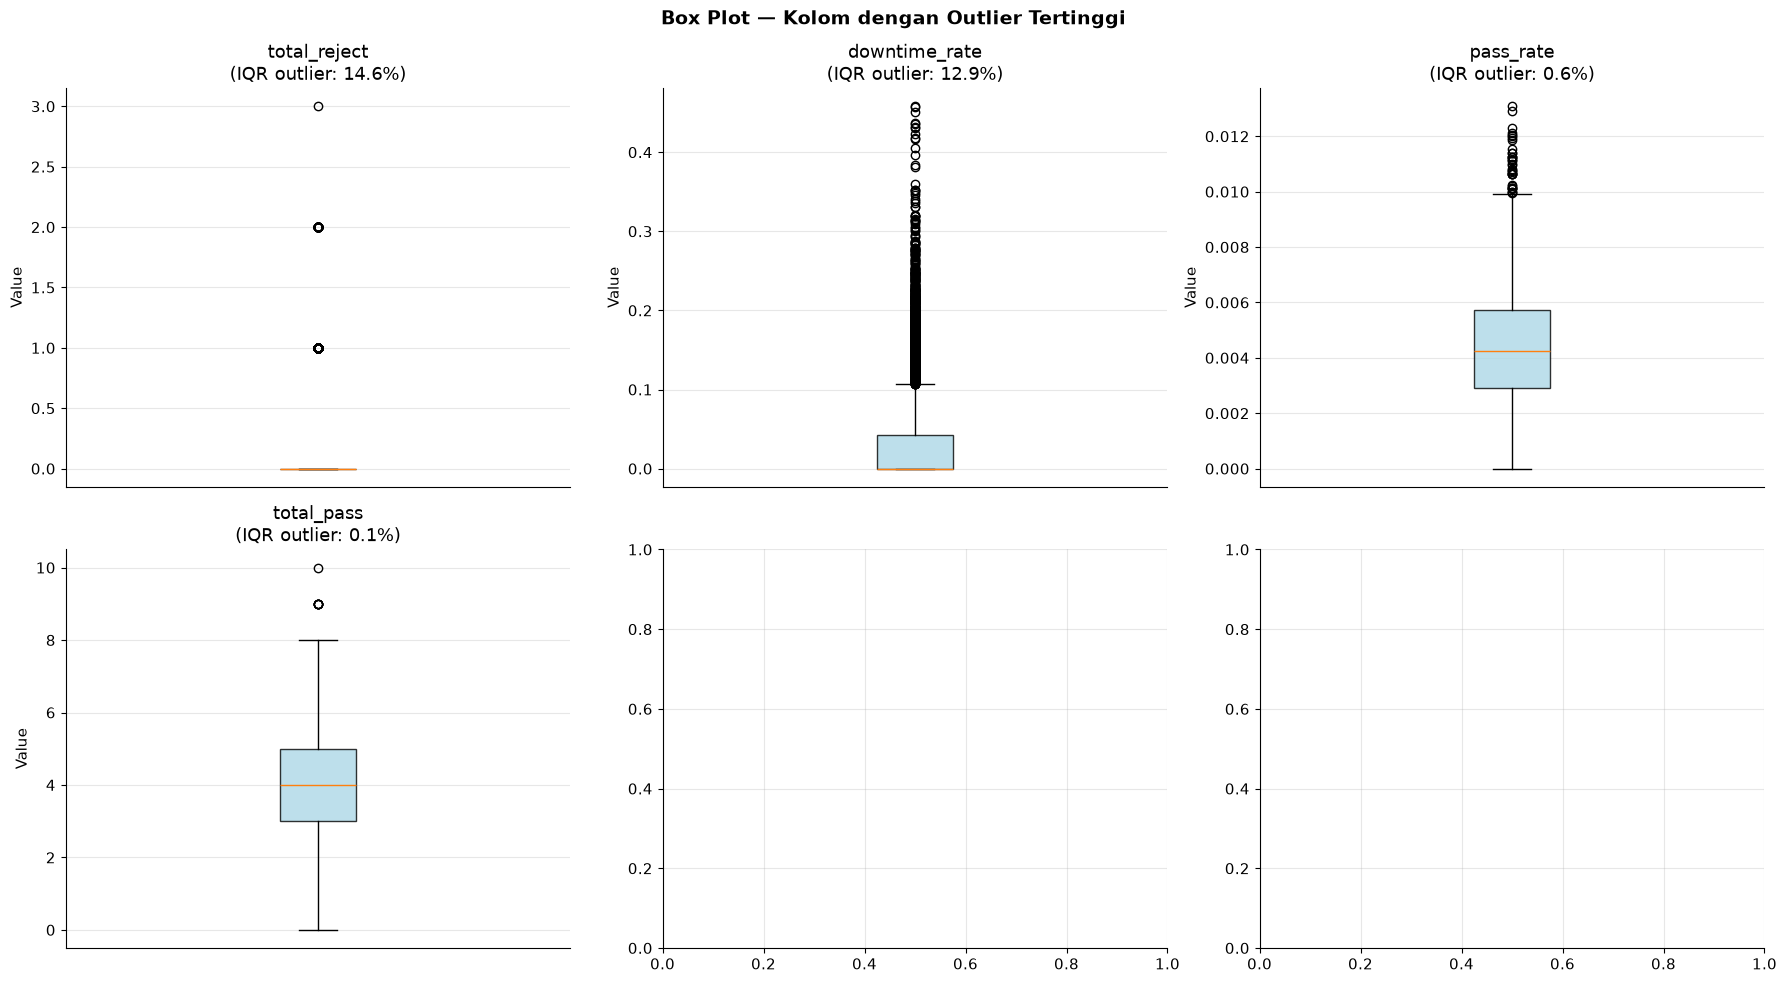

In [17]:
# ── 7.2 Visualisasi Outlier (Box Plot) ────────────────────────────────────────
# Pilih 6 kolom dengan outlier terbanyak
top_outlier_cols = outlier_df[outlier_df['pct_outlier_iqr'] > 0].head(6).index.tolist()

if top_outlier_cols:
    n = len(top_outlier_cols)
    cols_per_row = 3
    n_rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(18, 5 * n_rows))
    axes = axes.flat

    for ax, col in zip(axes, top_outlier_cols):
        data = df[col].dropna()
        ax.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.8))
        pct = outlier_df.loc[col, 'pct_outlier_iqr']
        ax.set_title(f'{col}\n(IQR outlier: {pct:.1f}%)')
        ax.set_ylabel('Value')
        ax.set_xticks([])

    # Sembunyikan axis yang tidak digunakan
    for ax in list(axes)[len(top_outlier_cols):]:
        ax.set_visible(False)

    plt.suptitle('Box Plot — Kolom dengan Outlier Tertinggi', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('✅ Tidak ada kolom dengan outlier signifikan.')

In [18]:
# ── 7.3 Penanganan Outlier — Winsorizing (Capping) ────────────────────────────
#
# Strategi: WINSORIZING (capping)
# → Nilai di bawah lower bound → ganti dengan lower bound
# → Nilai di atas upper bound → ganti dengan upper bound
# → Lebih aman daripada hapus baris (data manufaktur bisa memiliki variasi ekstrem yang valid)
#
# Kolom yang TIDAK di-cap (karena nilai ekstrem bisa valid):
NO_CAP_COLS = [
    'total_downtime_seconds',  # Bisa 0 atau sangat besar (mesin mati lama)
    'downtime_count',
    'total_output',            # Variasi output natural
]

winsor_log = []

for col in OUTLIER_COLS:
    if col not in df.columns or col in NO_CAP_COLS:
        continue
    if outlier_df.loc[col, 'pct_outlier_iqr'] == 0:
        continue

    Q1   = df[col].quantile(0.25)
    Q3   = df[col].quantile(0.75)
    IQR  = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Pastikan tidak cap nilai rasio/rate di luar [0, 1]
    if col.endswith('_rate') or col in ['oee_line', 'availability', 'perfomance', 'quality',
                                          'efficiency', 'reject_rate', 'pass_rate']:
        lower = max(lower, 0.0)
        upper = min(upper, 1.0)

    n_capped_low  = (df[col] < lower).sum()
    n_capped_high = (df[col] > upper).sum()
    total_capped  = n_capped_low + n_capped_high

    if total_capped > 0:
        df[col] = df[col].clip(lower=lower, upper=upper)
        winsor_log.append({
            'kolom'     : col,
            'lower'     : round(lower, 4),
            'upper'     : round(upper, 4),
            'n_capped'  : int(total_capped),
            'pct_capped': round(total_capped / len(df) * 100, 2),
        })

print('📋 Laporan Winsorizing:')
if winsor_log:
    wlog_df = pd.DataFrame(winsor_log)
    print(wlog_df.to_string(index=False))
else:
    print('   ✅ Tidak ada nilai yang perlu di-cap.')

log_step('Outlier', 'Winsorizing (capping) outlier selesai', len(df), len(df),
         f'{len(winsor_log)} kolom di-cap')

📋 Laporan Winsorizing:
        kolom  lower  upper  n_capped  pct_capped
   total_pass 0.0000 8.0000         7      0.1100
 total_reject 0.0000 0.0000       927     14.6200
    pass_rate 0.0000 0.0099        36      0.5700
downtime_rate 0.0000 0.1071       818     12.9000
✅ [Outlier] Winsorizing (capping) outlier selesai
   Detail: 4 kolom di-cap


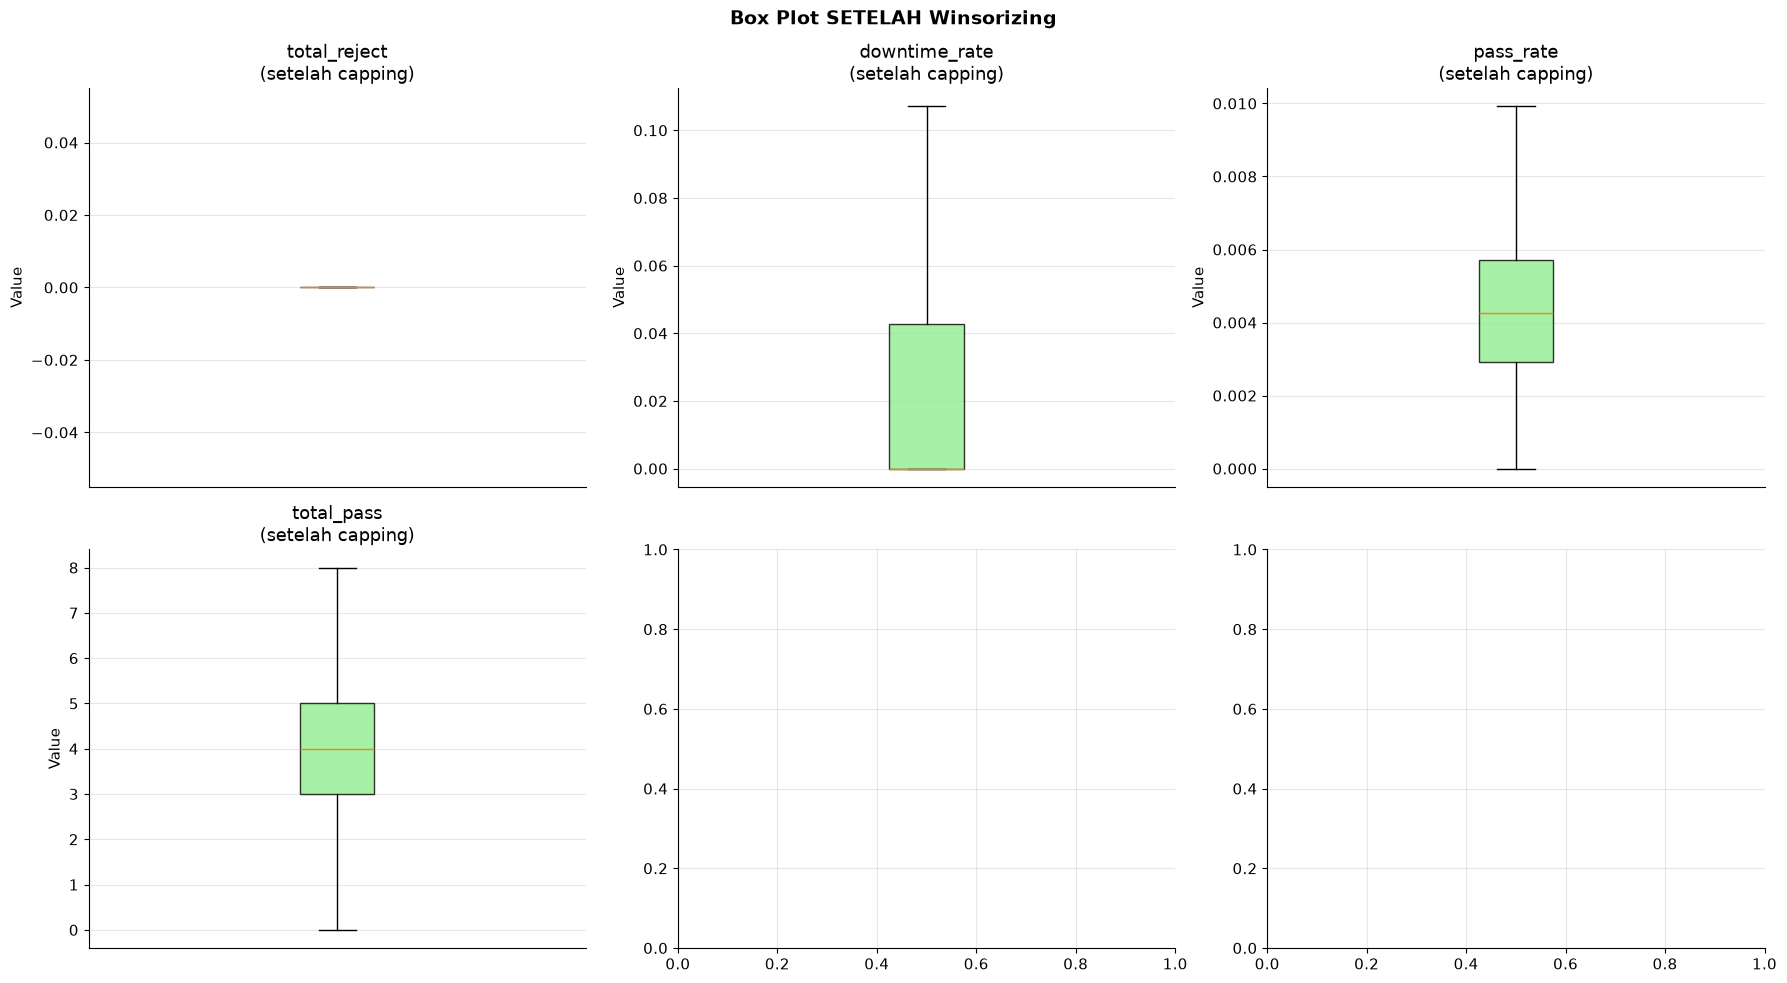

In [19]:
# ── 7.4 Verifikasi Setelah Winsorizing ────────────────────────────────────────
if top_outlier_cols:
    cols_to_check = [c for c in top_outlier_cols if c in df.columns]
    if cols_to_check:
        n   = len(cols_to_check)
        cpr = 3
        fig, axes = plt.subplots((n + cpr - 1) // cpr, cpr, figsize=(18, 5 * ((n + cpr - 1) // cpr)))
        axes = axes.flat
        for ax, col in zip(axes, cols_to_check):
            ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightgreen', alpha=0.8))
            ax.set_title(f'{col}\n(setelah capping)')
            ax.set_ylabel('Value')
            ax.set_xticks([])
        for ax in list(axes)[len(cols_to_check):]:
            ax.set_visible(False)
        plt.suptitle('Box Plot SETELAH Winsorizing', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

---
## 🔧 8. Perbaiki Inkonsistensi Struktural

In [20]:
# ── 8.1 Perbaiki Nama Kolom ───────────────────────────────────────────────────
# Kolom dengan typo di dataset asli
rename_map = {}
if 'perfomance' in df.columns:
    rename_map['perfomance'] = 'performance'
if 'troughput' in df.columns:
    rename_map['troughput'] = 'throughput'

if rename_map:
    df.rename(columns=rename_map, inplace=True)
    print(f'🔧 Kolom di-rename (perbaiki typo):')
    for old, new in rename_map.items():
        print(f'   · "{old}" → "{new}"')
else:
    print('✅ Tidak ada nama kolom yang perlu diperbaiki.')

🔧 Kolom di-rename (perbaiki typo):
   · "perfomance" → "performance"


In [21]:
# ── 8.2 Perbaiki Inkonsistensi Nilai Kategorikal ──────────────────────────────
str_cols = df.select_dtypes(include='object').columns
incon_log = []

for col in str_cols:
    unique_vals = df[col].unique()
    # Cek variasi whitespace atau kapitalisasi yang berbeda
    df[col] = df[col].astype(str).str.strip()
    new_unique = df[col].unique()
    if len(unique_vals) != len(new_unique):
        incon_log.append((col, len(unique_vals), len(new_unique)))
        print(f'   🔧 {col}: {len(unique_vals)} → {len(new_unique)} unique (whitespace diperbaiki)')

if not incon_log:
    print('✅ Tidak ada inkonsistensi nilai kategorikal ditemukan.')

✅ Tidak ada inkonsistensi nilai kategorikal ditemukan.


In [22]:
# ── 8.3 Validasi Range Logis Kolom Numerik ────────────────────────────────────
# Definisikan batasan logis untuk kolom tertentu
LOGICAL_BOUNDS = {
    'oee_line'              : (0.0, 1.0),
    'availability'          : (0.0, 1.0),
    'performance'           : (0.0, 1.0),
    'quality'               : (0.0, 1.0),
    'efficiency'            : (0.0, 1.0),
    'reject_rate'           : (0.0, 1.0),
    'pass_rate'             : (0.0, 1.0),
    'downtime_rate'         : (0.0, 1.0),
    'total_output'          : (0, None),
    'total_pass'            : (0, None),
    'total_reject'          : (0, None),
    'total_downtime_seconds': (0, None),
    'downtime_count'        : (0, None),
    'month'                 : (1, 12),
    'day_of_week'           : (0, 6),
    'shift_num'             : (1, 3),
    'line_encoded'          : (0, 3),
}

print('📋 Validasi Range Logis:')
violations = {}
for col, (lo, hi) in LOGICAL_BOUNDS.items():
    if col not in df.columns:
        continue
    series = df[col]
    v_low  = (series < lo).sum() if lo is not None else 0
    v_high = (series > hi).sum() if hi is not None else 0
    if v_low > 0 or v_high > 0:
        violations[col] = {'below_min': int(v_low), 'above_max': int(v_high)}
        print(f'   ⚠️  {col}: {v_low} < {lo}, {v_high} > {hi}')
        # Clip ke batas logis
        df[col] = df[col].clip(
            lower=lo if lo is not None else -np.inf,
            upper=hi if hi is not None else  np.inf
        )
        print(f'      → Di-clip ke [{lo}, {hi}]')
    else:
        print(f'   ✅ {col}: dalam range [{lo}, {hi}]')

log_step('Inkonsistensi', 'Perbaiki inkonsistensi struktural', len(df), len(df),
         f'{len(rename_map)} rename, {len(violations)} range violations')

📋 Validasi Range Logis:
   ✅ availability: dalam range [0.0, 1.0]
   ✅ performance: dalam range [0.0, 1.0]
   ✅ quality: dalam range [0.0, 1.0]
   ✅ efficiency: dalam range [0.0, 1.0]
   ✅ pass_rate: dalam range [0.0, 1.0]
   ✅ downtime_rate: dalam range [0.0, 1.0]
   ✅ total_output: dalam range [0, None]
   ✅ total_pass: dalam range [0, None]
   ✅ total_reject: dalam range [0, None]
   ✅ downtime_count: dalam range [0, None]
   ✅ day_of_week: dalam range [0, 6]
   ✅ line_encoded: dalam range [0, 3]
✅ [Inkonsistensi] Perbaiki inkonsistensi struktural
   Detail: 1 rename, 0 range violations


In [23]:
# ── 8.4 Pastikan Konsistensi Kalkulasi Internal ───────────────────────────────
# total_pass + total_reject ≤ total_output
if all(c in df.columns for c in ['total_pass', 'total_reject', 'total_output']):
    df['total_pass']   = df['total_pass'].astype(float)
    df['total_reject'] = df['total_reject'].astype(float)
    df['total_output'] = df['total_output'].astype(float)

    inconsistent = df['total_pass'] + df['total_reject'] > df['total_output']
    n_incon = inconsistent.sum()
    if n_incon:
        print(f'⚠️  {n_incon} baris di mana total_pass + total_reject > total_output')
        # Koreksi: set total_reject = total_output - total_pass (floor 0)
        df.loc[inconsistent, 'total_reject'] = (
            df.loc[inconsistent, 'total_output'] - df.loc[inconsistent, 'total_pass']
        ).clip(lower=0)
        print(f'   → Diperbaiki: total_reject = total_output - total_pass')
    else:
        print('✅ Konsistensi total_pass + total_reject ≤ total_output: OK')

# reject_rate = total_reject / total_output
if all(c in df.columns for c in ['reject_rate', 'total_reject', 'total_output']):
    df['reject_rate'] = (df['total_reject'] / df['total_output'].replace(0, np.nan)).fillna(0)
    print('✅ reject_rate direcalculate dari total_reject / total_output')

# pass_rate = total_pass / total_output
if all(c in df.columns for c in ['pass_rate', 'total_pass', 'total_output']):
    df['pass_rate'] = (df['total_pass'] / df['total_output'].replace(0, np.nan)).fillna(0)
    print('✅ pass_rate direcalculate dari total_pass / total_output')

✅ Konsistensi total_pass + total_reject ≤ total_output: OK
✅ pass_rate direcalculate dari total_pass / total_output


---
## ✅ 9. Validasi Dataset Bersih

In [24]:
# ── 9.1 Pemeriksaan Akhir ─────────────────────────────────────────────────────
print('=' * 65)
print('  VALIDASI DATASET BERSIH')
print('=' * 65)

checks = {}

# Cek 1: Tidak ada missing values
total_null = df.isnull().sum().sum()
checks['Missing values'] = ('✅ PASS' if total_null == 0 else f'❌ FAIL ({total_null} null)', total_null)

# Cek 2: Tidak ada duplikat
total_dup = df.duplicated().sum()
checks['Duplikat'] = ('✅ PASS' if total_dup == 0 else f'❌ FAIL ({total_dup} dup)', total_dup)

# Cek 3: Kolom numerik tidak ada inf
num_cols = df.select_dtypes(include='number').columns
total_inf = np.isinf(df[num_cols].values).sum()
checks['Infinite values'] = ('✅ PASS' if total_inf == 0 else f'❌ FAIL ({total_inf} inf)', total_inf)

# Cek 4: Shape reasonable
min_rows = ORIGINAL_SHAPE[0] * 0.8  # Tidak boleh berkurang > 20%
checks['Row count'] = (
    f'✅ PASS ({len(df):,} rows)' if len(df) >= min_rows
    else f'⚠️ WARNING ({len(df):,} rows, turun {(1 - len(df)/ORIGINAL_SHAPE[0])*100:.1f}%)',
    len(df)
)

# Cek 5: Tidak ada kolom all-zero numerik
zero_cols = [c for c in num_cols if df[c].sum() == 0]
checks['All-zero columns'] = (
    '✅ PASS' if not zero_cols else f'⚠️ WARNING: {zero_cols}', len(zero_cols)
)

# Print hasil
for check, (status, _) in checks.items():
    print(f'   {check:<25} : {status}')

print()
print(f'   Shape awal   : {ORIGINAL_SHAPE[0]:,} rows × {ORIGINAL_SHAPE[1]} kolom')
print(f'   Shape bersih : {df.shape[0]:,} rows × {df.shape[1]} kolom')
print('=' * 65)

  VALIDASI DATASET BERSIH
   Missing values            : ✅ PASS
   Duplikat                  : ✅ PASS
   Infinite values           : ✅ PASS
   Row count                 : ✅ PASS (6,340 rows)
   All-zero columns          : ⚠️ WARNING: ['total_reject']

   Shape awal   : 6,340 rows × 27 kolom
   Shape bersih : 6,340 rows × 18 kolom


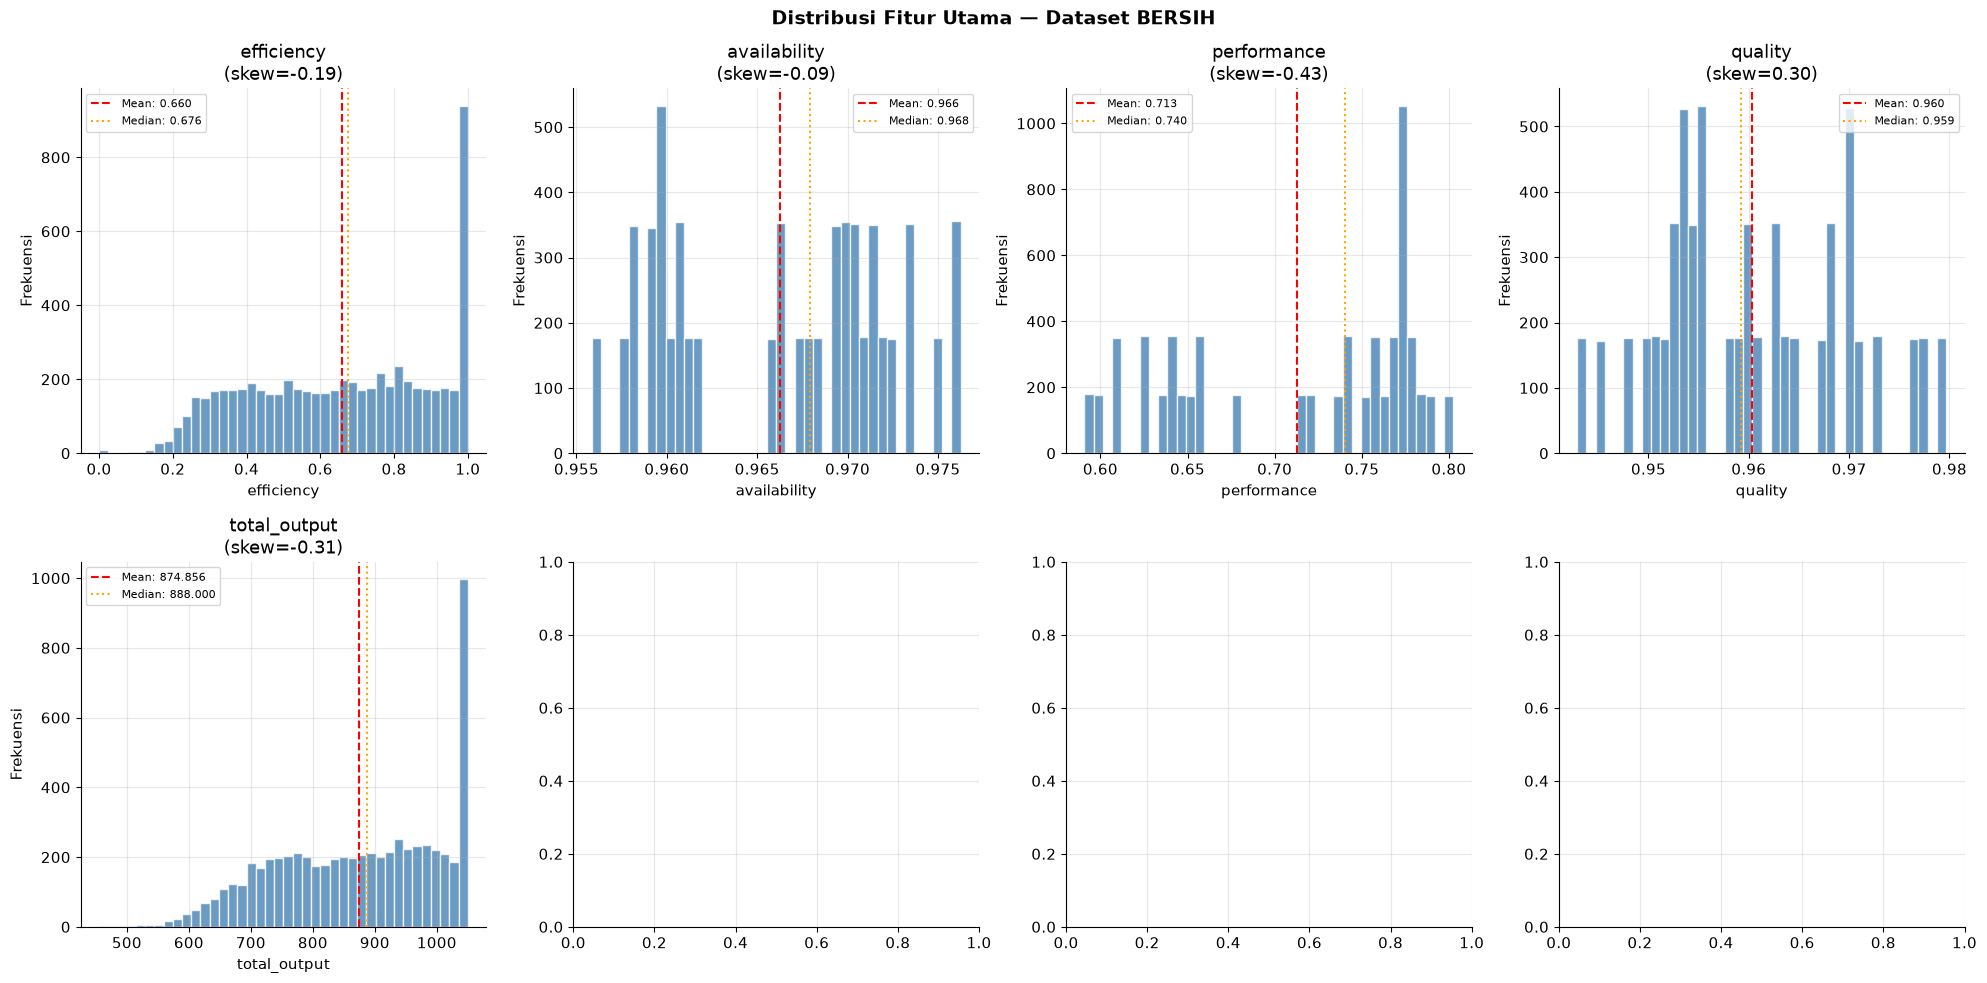

In [25]:
# ── 9.2 Visualisasi Distribusi Setelah Cleaning ───────────────────────────────
key_cols = [
    c for c in ['oee_line', 'efficiency', 'availability', 'performance',
                 'quality', 'total_output', 'reject_rate', 'throughput']
    if c in df.columns
]

if key_cols:
    n   = len(key_cols)
    cpr = 4
    fig, axes = plt.subplots((n + cpr - 1) // cpr, cpr, figsize=(20, 5 * ((n + cpr - 1) // cpr)))
    axes = axes.flat

    for ax, col in zip(axes, key_cols):
        data = df[col].dropna()
        ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f'Mean: {data.mean():.3f}')
        ax.axvline(data.median(), color='orange', linestyle=':', linewidth=1.5,
                   label=f'Median: {data.median():.3f}')
        ax.set_title(f'{col}\n(skew={data.skew():.2f})')
        ax.set_xlabel(col)
        ax.set_ylabel('Frekuensi')
        ax.legend(fontsize=8)

    for ax in list(axes)[len(key_cols):]:
        ax.set_visible(False)

    plt.suptitle('Distribusi Fitur Utama — Dataset BERSIH', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [26]:
# Statistik deskriptif akhir
print('📊 Statistik Deskriptif Dataset Bersih:')
df.describe(include='all').T

📊 Statistik Deskriptif Dataset Bersih:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recorded_date,6340,182,2026-02-03,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
line_name,6340,4,line b,1594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shift_name,6340,3,shift 2,2115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
recorded_hour,6340.0000,NaN,NaN,NaN,14.0038,6.5312,6.0000,6.0000,14.0000,22.0000,22.0000
day_of_week,6340.0000,NaN,NaN,NaN,2.9420,1.9723,0.0000,1.0000,3.0000,5.0000,6.0000
week_of_year,6340.0000,NaN,NaN,NaN,18.3554,7.4695,5.0000,12.0000,18.0000,25.0000,31.0000
is_weekend,6340.0000,NaN,NaN,NaN,0.2669,0.4424,0.0000,0.0000,0.0000,1.0000,1.0000
line_encoded,6340.0000,NaN,NaN,NaN,1.5000,1.1177,0.0000,1.0000,1.0000,3.0000,3.0000
total_output,6340.0000,NaN,NaN,NaN,874.8558,132.2063,455.0000,767.0000,888.0000,992.0000,1050.0000
total_pass,6340.0000,NaN,NaN,NaN,3.8192,1.5010,0.0000,3.0000,4.0000,5.0000,8.0000


---
## 💾 10. Simpan Dataset Bersih

In [27]:
# ── 10.1 Simpan Dataset Bersih ────────────────────────────────────────────────
OUTPUT_FILE = PROCESSED_DIR / 'df_cleaned.csv'
df.to_csv(OUTPUT_FILE, index=False)

size_kb = OUTPUT_FILE.stat().st_size / 1024
print(f'✅ Dataset bersih tersimpan:')
print(f'   Path   : {OUTPUT_FILE}')
print(f'   Shape  : {df.shape[0]:,} rows × {df.shape[1]} kolom')
print(f'   Size   : {size_kb:.1f} KB')

# Simpan juga versi per use-case (sudah bersih)
USE_CASES = {
    'oee_prediction'     : 'oee_line',
    'output_forecast'    : 'total_output',
    'reject_prediction'  : 'total_reject',
    'efficiency_forecast': 'efficiency',
}

# Kolom fitur (non-target)
META_COLS   = ['recorded_date', 'line_name', 'shift_name']
ALL_TARGETS = list(USE_CASES.values())
FEATURE_ONLY = [
    c for c in df.columns
    if c not in META_COLS and c not in ALL_TARGETS
]

print()
for use_case, target_col in USE_CASES.items():
    if target_col not in df.columns:
        print(f'⚠️  [{use_case}] kolom target "{target_col}" tidak ada, skip.')
        continue
    cols = FEATURE_ONLY + [target_col]
    df_uc = df[[c for c in cols if c in df.columns]].dropna()
    path_uc = PROCESSED_DIR / f'df_cleaned_{use_case}.csv'
    df_uc.to_csv(path_uc, index=False)
    print(f'✅ [{use_case}] → {path_uc.name}  ({df_uc.shape[0]:,} rows × {df_uc.shape[1]} cols)')

✅ Dataset bersih tersimpan:
   Path   : c:\AI\AI untuk Dashboard TA\New folder\dataset\processed\df_cleaned.csv
   Shape  : 6,340 rows × 18 kolom
   Size   : 912.0 KB

⚠️  [oee_prediction] kolom target "oee_line" tidak ada, skip.
✅ [output_forecast] → df_cleaned_output_forecast.csv  (6,340 rows × 13 cols)
✅ [reject_prediction] → df_cleaned_reject_prediction.csv  (6,340 rows × 13 cols)
✅ [efficiency_forecast] → df_cleaned_efficiency_forecast.csv  (6,340 rows × 13 cols)


In [28]:
# ── 10.2 Simpan Laporan Cleaning ──────────────────────────────────────────────
report = {
    'timestamp'       : datetime.now().isoformat(),
    'input_file'      : str(INPUT_FILE),
    'output_file'     : str(OUTPUT_FILE),
    'shape_before'    : {'rows': ORIGINAL_SHAPE[0], 'cols': ORIGINAL_SHAPE[1]},
    'shape_after'     : {'rows': df.shape[0],        'cols': df.shape[1]},
    'rows_removed'    : ORIGINAL_SHAPE[0] - df.shape[0],
    'cols_removed'    : ORIGINAL_SHAPE[1] - df.shape[1],
    'cleaning_steps'  : cleaning_log,
    'imputation'      : imputation_report,
    'winsorizing'     : winsor_log if winsor_log else [],
    'dropped_cols'    : drop_reasons,
    'renamed_cols'    : rename_map,
    'final_columns'   : list(df.columns),
    'validation'      : {k: str(v[0]) for k, v in checks.items()},
}

report_path = PROCESSED_DIR / 'cleaning_report.json'
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2, default=str)

print(f'✅ Laporan cleaning tersimpan: {report_path}')

✅ Laporan cleaning tersimpan: c:\AI\AI untuk Dashboard TA\New folder\dataset\processed\cleaning_report.json


In [29]:
# ── 10.3 Tampilkan Semua File di Folder Processed ─────────────────────────────
print('\n📂 Isi folder dataset/processed/:')
print(f'   {"Nama File":<50} {"Size":>10}')
print('   ' + '-' * 62)
for f in sorted(PROCESSED_DIR.iterdir()):
    size = f.stat().st_size
    size_str = f'{size/1024:.1f} KB' if size < 1024**2 else f'{size/1024**2:.2f} MB'
    icon = '📊' if f.suffix == '.csv' else '📄'
    print(f'   {icon} {f.name:<48} {size_str:>10}')


📂 Isi folder dataset/processed/:
   Nama File                                                Size
   --------------------------------------------------------------
   📄 cleaning_report.json                                 3.0 KB
   📊 df_cleaned.csv                                     912.0 KB
   📊 df_cleaned_efficiency_forecast.csv                 687.6 KB
   📊 df_cleaned_oee_prediction.csv                       1.07 MB
   📊 df_cleaned_output_forecast.csv                     686.1 KB
   📊 df_cleaned_reject_prediction.csv                   672.3 KB
   📊 df_efficiency_forecast.csv                          1.04 MB
   📊 df_model_full.csv                                   1.31 MB
   📊 df_oee_prediction.csv                               1.11 MB
   📊 df_output_forecast.csv                              1.05 MB
   📊 df_reject_prediction.csv                            1.02 MB
   📊 line.csv                                             0.4 KB
   📊 machine.csv                                       

---
## 📋 11. Ringkasan Proses Data Cleaning

In [30]:
print('=' * 70)
print('  RINGKASAN DATA CLEANING — PT VOLEX MMS DATASET')
print('=' * 70)

print(f'''
📌 SEBELUM vs SESUDAH
  Shape awal    : {ORIGINAL_SHAPE[0]:,} rows × {ORIGINAL_SHAPE[1]} kolom
  Shape bersih  : {df.shape[0]:,} rows × {df.shape[1]} kolom
  Baris dihapus : {ORIGINAL_SHAPE[0] - df.shape[0]:,}
  Kolom dihapus : {ORIGINAL_SHAPE[1] - df.shape[1]}

📌 TAHAPAN CLEANING
  1. Missing Values  → {len(imputation_report)} kolom diimputasi (median/mode)
  2. Duplikasi       → {sum(1 for s in cleaning_log if s["step"] == "Duplikasi" and s["removed"] > 0)} step, {next((s["removed"] for s in cleaning_log if s["step"] == "Duplikasi"), 0)} baris dihapus
  3. Tipe Data       → float32 optimasi, datetime parse, rename typo
  4. Fitur Irrelevan → {len(cols_to_drop_existing)} kolom dihapus
  5. Outlier (IQR)   → Winsorizing pada {len(winsor_log)} kolom
  6. Range Logis     → Clip nilai di luar batas wajar
  7. Konsistensi     → Recalculate reject_rate, pass_rate

📌 OUTPUT FILE
  • df_cleaned.csv                    → Dataset bersih lengkap
  • df_cleaned_oee_prediction.csv     → Siap training OEE model
  • df_cleaned_output_forecast.csv    → Siap training Output forecast
  • df_cleaned_reject_prediction.csv  → Siap training Defect model
  • df_cleaned_efficiency_forecast.csv→ Siap training Efficiency model
  • cleaning_report.json              → Laporan cleaning lengkap

📌 LANGKAH SELANJUTNYA
  → Feature Scaling (StandardScaler / MinMaxScaler)
  → Encoding kategorikal (jika ada)
  → Train-Test Split
  → Model Training (XGBoost / LSTM / Random Forest)
''')
print('=' * 70)
print('  ✅ DATA CLEANING SELESAI — DATASET SIAP UNTUK AI MODEL!')
print('=' * 70)

  RINGKASAN DATA CLEANING — PT VOLEX MMS DATASET

📌 SEBELUM vs SESUDAH
  Shape awal    : 6,340 rows × 27 kolom
  Shape bersih  : 6,340 rows × 18 kolom
  Baris dihapus : 0
  Kolom dihapus : 9

📌 TAHAPAN CLEANING
  1. Missing Values  → 0 kolom diimputasi (median/mode)
  2. Duplikasi       → 0 step, 0 baris dihapus
  3. Tipe Data       → float32 optimasi, datetime parse, rename typo
  4. Fitur Irrelevan → 9 kolom dihapus
  5. Outlier (IQR)   → Winsorizing pada 4 kolom
  6. Range Logis     → Clip nilai di luar batas wajar
  7. Konsistensi     → Recalculate reject_rate, pass_rate

📌 OUTPUT FILE
  • df_cleaned.csv                    → Dataset bersih lengkap
  • df_cleaned_oee_prediction.csv     → Siap training OEE model
  • df_cleaned_output_forecast.csv    → Siap training Output forecast
  • df_cleaned_reject_prediction.csv  → Siap training Defect model
  • df_cleaned_efficiency_forecast.csv→ Siap training Efficiency model
  • cleaning_report.json              → Laporan cleaning lengkap

📌 